## 1. ViT(Vistion Transformer)
ViT(Vision Transformer)는 이미지를 일정 크기의 패치(예: 16×16)로 나눈 뒤 각 패치를 임베딩 벡터로 투영해 토큰 시퀀스로 만들고, 여기에 위치 임베딩을 더해 트랜스포머 인코더(멀티헤드 자기어텐션+FFN)로 처리하여 분류 등의 다운스트림 작업을 수행하는 모델입니다. 

분류의 경우 BERT처럼 맨 앞에 [CLS] 토큰을 두고 그 출력으로 최종 예측을 합니다. 

CNN이 지역적 합성곱과 계층적 다운샘플링으로 전역 정보를 “깊이”에서 얻게 되는 반면, ViT는 자기어텐션으로 처음부터 전역 관계를 직접 학습하는 것이 특징입니다. 

충분한 데이터와 적절한 사전학습·증강이 있을 때 스케일이 클수록 성능이 잘 향상되지만, 어텐션의 계산량이 토큰 수 제곱(O(N²))에 비례해 해상도가 높거나 패치가 너무 작으면 비용이 크게 늘 수 있습니다.

![vit](./image%203.png)

> NLP Transformer에서 단어(Token)가 들어가던 자리에 ViT에서 이미지 patch token이 들어감

### 1. NLP Transformer
- 문장을 Token으로 분리
- Token ID > Embedding
- [CLS] Token
- Position Embedding을 함
- Multi-Head Self-Attention
- FFN/MLP
- 문장 분류

### 2. Vision Transformer
- 이미지를 Patch로 분리
- Patch > Linear Projection
- [CLS] Token 넣어주기
- Position Encoding
- Multi-Head Self-Attention
- FFN/MLP
- 이미지 분류

```
예) 이미지 (3, 224, 224)
patch의 크기: 16x16
한 변: 14*14 => 196
[CLS] Token 추가 > 패치수의 수 197
```

- 위 내용으로 NLP의 Self-Attention과 계산 원리는 같음
- 각 patch가 Query, Key, Value를 만들고, 다른 모든 patchh와의 관계를 계산

In [1]:
from pathlib import Path
import json
import random
import math
import time
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [3]:
rng = np.random.default_rng(SEED)
rng

Generator(PCG64) at 0x12ABD14A260

In [4]:
image = rng.random((8, 8, 3), dtype=np.float32)

patch_size = 4

In [5]:
h, w, c = image.shape

patches = image.reshape(h // patch_size, patch_size, w // patch_size, patch_size, c)
patches.shape

(2, 4, 2, 4, 3)

In [6]:
patches

array([[[[[0.851852  , 0.17893481, 0.02641749],
          [0.63991314, 0.36547762, 0.46726835],
          [0.07982802, 0.3705005 , 0.6434511 ],
          [0.3549173 , 0.83106107, 0.7905182 ]],

         [[0.7044274 , 0.9051438 , 0.7212086 ],
          [0.17735314, 0.8584549 , 0.65278476],
          [0.09846669, 0.2983027 , 0.1656735 ],
          [0.96696216, 0.72796   , 0.9198501 ]]],


        [[[0.28249913, 0.63587075, 0.6041742 ],
          [0.75273204, 0.11801624, 0.51515365],
          [0.64454323, 0.82589525, 0.6560865 ],
          [0.44838053, 0.4601344 , 0.3388124 ]],

         [[0.15723962, 0.2778992 , 0.14612716],
          [0.22633302, 0.8537974 , 0.5258168 ],
          [0.09160054, 0.43091202, 0.2707855 ],
          [0.6631806 , 0.8302993 , 0.01284045]]],


        [[[0.4658183 , 0.44770187, 0.9907011 ],
          [0.3651808 , 0.16521877, 0.19539756],
          [0.47755182, 0.59486586, 0.32656628],
          [0.4353131 , 0.66328   , 0.2999915 ]],

         [[0.9647345 , 0.2

In [7]:
patches = patches.transpose(0, 2, 1, 3, -1)
patches.shape

(2, 2, 4, 4, 3)

In [8]:
patches = patches.reshape(-1, patch_size, patch_size, c)
patches.shape

(4, 4, 4, 3)

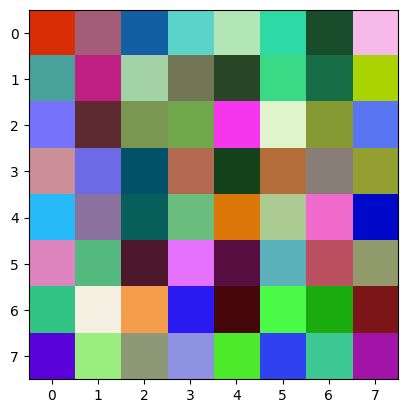

In [9]:
plt.imshow(image)

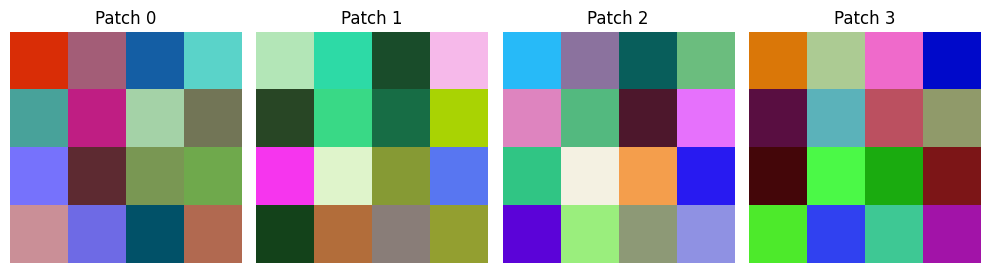

In [10]:
fig, axes = plt.subplots(1, len(patches), figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(patches[i])
    ax.set_title(f"Patch {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

- kernel_size = 16, stride = 16인 convolution은 서로 겹치지 않는 16*16 영역을 한 번씩 확인
- 출력 channel을 embed_dim으로 설명하면 각 patch를 embed_dim 차원의 vector로 바꾸는 효과가 나게됨
- (Patch 자르기 > Flatten > Linear) == Conv2d(kernel=patch_size, stride=patch_size)

```
Linear를 이용
첫 번째 patch > Flatten [1, 2, 5, 6] > Linear(4, 8) > [0.2, 0.5, ....]
[1 2]
[5 6]

Conv2d를 이용
nn.Conv2d(in_channels=1, out_channels=8, kernel_size=2, stride=2)
하나의 패치 kernel1: 0.2, kernel2: 0.5, kernel3: 0.1 ... kernel8: 0.6
```

In [11]:
class Patchembedding(nn.Module):
    def __init__(self, patch_size=4, in_channels=3, embed_dim=32):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # [1, 3, 8, 8]
        x = self.proj(x)
        # x: (B, D, H/P, W/P) [1, 32, 2, 2]
        x = x.flatten(2)
        # 2차원 이후를 하나로 합치기
        x = x.transpose(1, 2)
        # x: (B, N, D)
        return x

In [12]:
sample = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0)
print(sample.shape)

torch.Size([1, 3, 8, 8])


In [13]:
sample = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0)
print(sample.shape)

patch_embed = Patchembedding(patch_size=4, in_channels=3, embed_dim=32)
tokens = patch_embed(sample)

print("토큰: ", tokens.shape)

torch.Size([1, 3, 8, 8])
토큰:  torch.Size([1, 4, 32])


# [CLS] Token과 Position Embedding

- Self-Attention 자체에는 순서나 위치 개념이 없음
- patch가 이미지의 어느 위치에서 왔는지 알려주는 Position Embedding이 필요
- [CLS] token은 NLP의 BERT에서 사용하던 방식과 매우 유사
- 모든 patch와 attention을 주고 받으면서 이미지 전체를 대표하는 표현으로 학습되고, 마지막에 이 token을 classification head에 넣어줌

In [14]:
# B: 이미지 개수
# N: 이미지 한 장을 4개의 Patch로 나눔
# D: 각 Patch를 32개의 숫자로 표현
# Patch Embedding이 끝난 후, [CLS] Token과 Position Embedding을 추가하는 과정
B, N, D = tokens.shape
cls_token = nn.Parameter(torch.zeros(1, 1, D)) # (1, 1, 32)
pos_embed = nn.Parameter(torch.zeros(1, N+1, D)) # [CLS] 토큰
nn.init.trunc_normal_(cls_token, std=0.02)
nn.init.trunc_normal_(pos_embed, std=0.02)
# cls_token: (1, 1, 32) > expand(8, -1, -1) > (8, 1, 32)
# expand(): Batch에 크기에 맞게 [CLS] Token을 확장. -1 기존 크기를 유지
# expand 데이터를 실제로 복사하지 않고, 같은 데이터를 참조하는 확장된 View 만듦
# Patch1 Patch2 Patch3 Patch2 > [CLS] Patch1 Patch2 Patch3 Patch2
x = torch.cat([cls_token.expand(B, -1, -1), tokens], dim=1)
# x: (1, 5, 32), pos_embed: (1, 5, 32)
x = x + pos_embed
print('Patch token 수: ', N)
print('CLS 추가 후: ', x.shape)

Patch token 수:  4
CLS 추가 후:  torch.Size([1, 5, 32])


### Transformer Encoder에 넣기

```
입력 > LayerNorm > Multi-Head self-Attention > FFN > 출력

D: 차원  
nhead: Multi-Head self-Attention, n개 사용 > 서로 다른 관계를 학습할 기회  
dim_feedforward: 표현을 더 풍부하게 변환하는 역할
batch_first: (B, N, D)
norm_first: Layer Norm을 Attention과 FFN보다 먼저 할 것인지 설정
```

In [15]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=D, nhead=4, dim_feedforward=D*4, dropout=0.1, activation="gelu",
    batch_first=True, norm_first=True
)

encoder  = nn.TransformerEncoder(encoder_layer, num_layers=2, norm=nn.LayerNorm(D))
z = encoder(x)
classifier = nn.Linear(D, 10)
logits = classifier(z[:, 0])

print("Encoder 출력: ", z.shape)
print("분류 logits: ", logits.shape)
print("예측 class: ", logits.argmax(dim=1).item())

Encoder 출력:  torch.Size([1, 5, 32])
분류 logits:  torch.Size([1, 10])
예측 class:  3


C:\Users\hurwa\AppData\Local\Temp\ipykernel_587816\2330189342.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  encoder  = nn.TransformerEncoder(encoder_layer, num_layers=2, norm=nn.LayerNorm(D))


In [16]:
DATA_ROOT = Path("./data/ViT")

ANNOTATION_PATH = DATA_ROOT / "annotations.json"
IMAGE_DIR = DATA_ROOT / "images"
MODEL_DIR = Path("./vit_train_results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT       :", DATA_ROOT.resolve())
print("ANNOTATION_PATH :", ANNOTATION_PATH.resolve())
print("IMAGE_DIR       :", IMAGE_DIR.resolve())

DATA_ROOT       : C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\2026_09_11_NLP\data\ViT
ANNOTATION_PATH : C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\2026_09_11_NLP\data\ViT\annotations.json
IMAGE_DIR       : C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\2026_09_11_NLP\data\ViT\images


In [17]:
with ANNOTATION_PATH.open("r", encoding="utf-8") as f:
    annotations = json.load(f)

print("전체 데이터 개수:", len(annotations))
print("첫 annotation:", annotations[0])

전체 데이터 개수: 36828
첫 annotation: {'filename': '21구2298.jpg', 'labels': '2298'}


In [18]:
from collections import Counter

position_counts = [Counter() for _ in range(4)]

for item in annotations:
    for pos, label in enumerate(item["labels"]):
        position_counts[pos][int(label)] += 1

for pos, counts in enumerate(position_counts, start=1):
    print(f"\n{pos}번째 자리 분포")
    print(dict(sorted(counts.items())))


1번째 자리 분포
{0: 3978, 1: 4091, 2: 3617, 3: 3505, 4: 3611, 5: 4056, 6: 4110, 7: 3340, 8: 3535, 9: 2985}

2번째 자리 분포
{0: 3426, 1: 3876, 2: 3793, 3: 3769, 4: 3644, 5: 3762, 6: 3698, 7: 3683, 8: 3645, 9: 3532}

3번째 자리 분포
{0: 3647, 1: 3663, 2: 3762, 3: 3597, 4: 3550, 5: 3948, 6: 3789, 7: 3631, 8: 3623, 9: 3618}

4번째 자리 분포
{0: 3594, 1: 3755, 2: 3658, 3: 3694, 4: 3440, 5: 3681, 6: 3595, 7: 3866, 8: 3785, 9: 3760}


In [19]:
indices = np.arange(len(annotations))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

split = int(len(indices) * 0.9)
train_idx = indices[:split]
val_idx = indices[split:]

train_annot = [annotations[i] for i in train_idx]
val_annot = [annotations[i] for i in val_idx]

print("Train:", len(train_annot))
print("Val  :", len(val_annot))

Train: 33145
Val  : 3683


### torchvision.ToTensor
- 입력 PIL Image, Numpy 배열
- 출력: Pytorch Tensor
- 차원 변경 > HWC > CHW
- 픽셀: uint8 이미지 일 경우 0~255 > 0~1

### albumentations.pytorch.ToTensorV2
- 입력: Numpy 배열
- 출력: PyTorch Tensor
- 차원 변경: HWC > CHW
- 픽셀: 기본적으로 값 유지 (0~1 정규화 아님)

In [20]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [21]:
IMAGE_SIZE=224

In [22]:
train_transform = A.Compose([
  A.Affine(
    scale=(0.92, 1.08),
    translate_percent=(-0.04, 0.04),
    rotate=(-8, 8),
    shear=(-3, 3),
    border_mode=0,
    p=0/6
  ),
  A.RandomBrightnessContrast(
    brightness_limit=0.15,
    contrast_limit=0.15,
    p=0.3
  ),
  A.LongestMaxSize(max_size=IMAGE_SIZE),
  A.PadIfNeeded(
    min_height=IMAGE_SIZE,
    min_width=IMAGE_SIZE,
    border_mode=0
  ),
  A.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
  ),
  ToTensorV2()
])

val_transform = A.Compose([
  A.PadIfNeeded(
    min_height=IMAGE_SIZE,
    min_width=IMAGE_SIZE,
    border_mode=0
  ),
  A.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
  ),
  ToTensorV2()
])

In [23]:
class JsonDataset(Dataset):
  def __init__(self, image_dir, annotations, transform=None):
    self.image_dir = Path(image_dir)
    self.annotations = annotations # idx list
    self.transform = transform
    self.num_classes = 10

  def __len__(self):
    return len(self.annotations)

  def __getitem__(self, idx):
    item = self.annotations[idx]
    image_path = self.image_dir / item["filename"]
    image = np.array(Image.open(image_path).convert("RGB"))
    target = torch.tensor([int(x) for x in item["labels"]], dtype=torch.long)

    if self.transform is not None:
      image = self.transform(image=image)["image"]
    return image, target

In [24]:
np.array(type(Image.open(r"C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\2026_09_11_NLP\data\ViT\images\01가1134-5.jpg").convert("RGB")))

array(<class 'PIL.Image.Image'>, dtype=object)

In [25]:
train_dataset = JsonDataset(IMAGE_DIR, train_annot, train_transform)
val_dataset = JsonDataset(IMAGE_DIR, val_annot, val_transform)

NUM_WORKERS = min(4, os.cpu_count() or 1) if os.name == "nt" else 0

NUM_WORKERS

4

In [26]:
len([a for a in Path("./data/ViT/images").iterdir()])

80000

In [27]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
  train_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  pin_memory=torch.cuda.is_available(),
  # num_workers=NUM_WORKERS,
  # persistent_workers=(NUM_WORKERS > 0),
  num_workers=0,
  persistent_workers=False
)

val_loader = DataLoader(
  val_dataset, 
  batch_size=BATCH_SIZE, 
  shuffle=False, 
  pin_memory=torch.cuda.is_available(), 
  # num_workers=NUM_WORKERS,
  # persistent_workers=(NUM_WORKERS > 0)
  num_workers=0,
  persistent_workers=False
)

In [28]:
images, targets = next(iter(train_dataloader))[:32]
print("images:", images.shape)
print("targets:", targets.shape)

images: torch.Size([32, 3, 224, 224])
targets: torch.Size([32, 4])
